In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 0. PATHS
# ------------------------------------------------------------

In [2]:
FILE_PATH = "ecommerce_eda_25000.csv"
OUTPUT_DIR = Path("ecommerce_eda_output")
OUTPUT_DIR.mkdir(exist_ok=True)



# IMPORTANT:
# Some environments have an invalid Matplotlib color cycle.
# Resetting Matplotlib defaults before Seaborn prevents:
# ValueError: Invalid RGBA argument: None

In [ ]:
plt.rcdefaults()
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

In [4]:
df = pd.read_csv(r'C:\Users\ukpra\OneDrive\Desktop\vs code phython\ecommerce data\ecommerce_eda_25000.csv')

print(df.head())

    Order_ID Customer_ID  Order_Date   Age  Gender    City        State  \
0  ORD111055   CUST14152  2025-11-05  18.0  Female  Mumbai  Maharashtra   
1  ORD106775   CUST11328  2025-09-01  24.0    Male  Mumbai  Maharashtra   
2  ORD121202   CUST17591  2025-11-24  38.0    Male  Mumbai  Maharashtra   
3  ORD113681   CUST14547  2024-03-01  19.0  Female  Jaipur    Rajasthan   
4  ORD124454   CUST17314  2025-07-22  33.0  Female  Mumbai  Maharashtra   

  Product_Category      Product_Name  Unit_Price  ...  Session_Duration_Min  \
0      Electronics  Wireless Earbuds    21245.42  ...                  38.5   
1          Grocery               Tea      563.58  ...                   4.2   
2          Fashion          Sneakers     5230.24  ...                  27.1   
3             Toys   Building Blocks     2652.42  ...                  19.7   
4          Fashion           T-Shirt     6796.23  ...                  19.5   

   Pages_Viewed  Add_to_Cart  Cart_Abandoned Returning_Customer  \
0      

# ------------------------------------------------------------
# 2. BASIC EDA
# ------------------------------------------------------------

In [5]:

print("\nShape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nInfo:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe(include="all").T)

print("\nMissing Values:")
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique().sort_values(ascending=False))


Shape: (25040, 30)

Data Types:
Order_ID                    str
Customer_ID                 str
Order_Date                  str
Age                     float64
Gender                      str
City                        str
State                       str
Product_Category            str
Product_Name                str
Unit_Price              float64
Quantity                  int64
Discount_Percentage     float64
Discount_Amount         float64
Total_Amount            float64
Payment_Method              str
Device_Type                 str
Order_Status                str
Shipping_Method             str
Delivery_Time_Days        int64
Customer_Rating         float64
Session_Duration_Min    float64
Pages_Viewed              int64
Add_to_Cart                 str
Cart_Abandoned              str
Returning_Customer          str
Marketing_Channel           str
Customer_Segment            str
Shipping_Cost           float64
Profit                  float64
Profit_Margin           float64
dtype: 


# ------------------------------------------------------------
# 3. DATA CLEANING
# ------------------------------------------------------------

In [6]:
clean_df = df.copy()

# Convert date

In [7]:
clean_df["Order_Date"] = pd.to_datetime(
    clean_df["Order_Date"], errors="coerce"
)

# Remove exact duplicates

In [8]:


duplicates_before = clean_df.duplicated().sum()
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# Text cleaning

In [9]:

text_cols = [
    "Gender", "City", "State", "Product_Category", "Product_Name",
    "Payment_Method", "Device_Type", "Order_Status",
    "Shipping_Method", "Add_to_Cart", "Cart_Abandoned",
    "Returning_Customer", "Marketing_Channel", "Customer_Segment"
]

for col in text_cols:
    clean_df[col] = clean_df[col].astype("string").str.strip()

# Invalid numeric values -> missing

In [10]:

clean_df.loc[~clean_df["Age"].between(18, 70), "Age"] = np.nan
clean_df.loc[clean_df["Quantity"] <= 0, "Quantity"] = np.nan
clean_df.loc[
    clean_df["Delivery_Time_Days"] <= 0, "Delivery_Time_Days"
] = np.nan
clean_df.loc[
    ~clean_df["Discount_Percentage"].between(0, 100),
    "Discount_Percentage"
] = np.nan
clean_df.loc[
    ~clean_df["Customer_Rating"].between(1, 5),
    "Customer_Rating"
] = np.nan

# Numeric missing values: median

In [11]:

numeric_fill_cols = [
    "Age",
    "Quantity",
    "Discount_Percentage",
    "Delivery_Time_Days",
    "Customer_Rating"
]

for col in numeric_fill_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Categorical missing values

In [12]:

categorical_fill_cols = [
    "City",
    "Payment_Method",
    "Shipping_Method"
]

for col in categorical_fill_cols:
    clean_df[col] = clean_df[col].fillna("Unknown")

# Recalculate financial columns

In [13]:

clean_df["Gross_Amount"] = (
    clean_df["Unit_Price"] * clean_df["Quantity"]
).round(2)

clean_df["Discount_Amount"] = (
    clean_df["Gross_Amount"]
    * clean_df["Discount_Percentage"]
    / 100
).round(2)

clean_df["Total_Amount"] = (
    clean_df["Gross_Amount"]
    - clean_df["Discount_Amount"]
).round(2)

clean_df["Profit"] = (
    clean_df["Total_Amount"]
    * clean_df["Profit_Margin"]
).round(2)

# Date features

In [14]:

clean_df["Year"] = clean_df["Order_Date"].dt.year
clean_df["Month"] = clean_df["Order_Date"].dt.month
clean_df["Month_Name"] = clean_df["Order_Date"].dt.month_name()
clean_df["Quarter"] = "Q" + clean_df["Order_Date"].dt.quarter.astype(str)
clean_df["Day_Name"] = clean_df["Order_Date"].dt.day_name()
clean_df["Year_Month"] = clean_df["Order_Date"].dt.to_period("M").astype(str)

print("Duplicates removed:", duplicates_before)
print("Cleaned shape:", clean_df.shape)
print("Remaining duplicates:", clean_df.duplicated().sum())
print("Remaining missing values:", clean_df.isna().sum().sum())

Duplicates removed: 40
Cleaned shape: (25000, 37)
Remaining duplicates: 0
Remaining missing values: 0


# Save cleaned file

In [15]:

clean_file = OUTPUT_DIR / "ecommerce_eda_25000_clean.csv"
clean_df.to_csv(clean_file, index=False)


# ------------------------------------------------------------
# 4. PANDAS BUSINESS ANALYSIS
# ------------------------------------------------------------


## category_analysis

In [16]:
category_analysis = (
    clean_df.groupby("Product_Category")
    .agg(
        Orders=("Order_ID", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Total_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Order_Value=("Total_Amount", "mean"),
        Avg_Rating=("Customer_Rating", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\nCATEGORY ANALYSIS")
print(category_analysis)


CATEGORY ANALYSIS
                  Orders  Quantity_Sold       Revenue       Profit  \
Product_Category                                                     
Electronics         4442         8826.0  2.063360e+08  37275255.47   
Home & Kitchen      4058         7941.0  6.226249e+07  11285870.66   
Fashion             4405         8607.0  2.678321e+07   4827416.87   
Sports              2009         3916.0  2.097905e+07   3690135.24   
Beauty              2967         5700.0  1.278046e+07   2327031.16   
Toys                2088         4122.0  1.106514e+07   1994377.09   
Grocery             3520         6922.0  7.392816e+06   1352273.21   
Books               1511         2940.0  3.342785e+06    598947.36   

                  Avg_Order_Value  Avg_Rating  
Product_Category                               
Electronics          46451.150180    3.992638  
Home & Kitchen       15343.146272    3.967176  
Fashion               6080.184052    3.965267  
Sports               10442.534903    3.9

## product_analysis

In [17]:
product_analysis = (
    clean_df.groupby("Product_Name")
    .agg(
        Orders=("Order_ID", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Total_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Rating=("Customer_Rating", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\nTOP 10 PRODUCTS")
print(product_analysis.head(10))


TOP 10 PRODUCTS
                   Orders  Quantity_Sold      Revenue      Profit  Avg_Rating
Product_Name                                                                 
Smartphone            907         1842.0  44148962.18  8026887.36    3.979934
Bluetooth Speaker     901         1788.0  42019454.64  7614708.09    4.028746
Smart Watch           897         1773.0  41314551.15  7595440.47    4.006800
Wireless Earbuds      868         1724.0  39749329.33  7090145.22    3.959793
Power Bank            869         1699.0  39103711.80  6948074.33    3.986651
Bedsheet              813         1586.0  12746227.60  2332828.05    3.970972
Mixer Grinder         827         1643.0  12698169.07  2270387.96    3.941475
Cookware Set          812         1596.0  12594868.81  2308501.71    3.995567
Air Fryer             792         1556.0  12233203.32  2243469.70    3.973106
Water Bottle          814         1560.0  11990018.77  2130683.24    3.955405


## city_analysis

In [18]:
city_analysis = (
    clean_df.groupby("City")
    .agg(
        Orders=("Order_ID", "count"),
        Revenue=("Total_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Order_Value=("Total_Amount", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\nTOP 10 CITIES")
print(city_analysis.head(10))


TOP 10 CITIES
           Orders      Revenue      Profit  Avg_Order_Value
City                                                       
Delhi        2536  38926146.30  7027555.74     15349.426774
Mumbai       2531  36476028.75  6713955.24     14411.706341
Bengaluru    2212  28991935.26  5106954.63     13106.661510
Hyderabad    2016  26739696.45  4917625.23     13263.738318
Chennai      1660  24006554.30  4146792.32     14461.779699
Kolkata      1520  20895859.09  3889276.49     13747.275717
Pune         1506  19840618.30  3579768.61     13174.381341
Jaipur       1227  17827289.95  3108777.44     14529.168663
Ahmedabad    1286  17660198.09  3198793.72     13732.657924
Lucknow      1229  17165156.28  3082940.62     13966.766705


## payment_analysis

In [19]:
payment_analysis = (
    clean_df.groupby("Payment_Method")
    .agg(
        Orders=("Order_ID", "count"),
        Revenue=("Total_Amount", "sum"),
        Avg_Order_Value=("Total_Amount", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\nPAYMENT ANALYSIS")
print(payment_analysis)


PAYMENT ANALYSIS
                  Orders       Revenue  Avg_Order_Value
Payment_Method                                         
UPI                 9475  1.287295e+08     13586.228470
Credit Card         5554  7.788908e+07     14023.961907
Debit Card          3902  5.750255e+07     14736.686609
Cash on Delivery    2950  4.298790e+07     14572.169800
Net Banking         1803  2.561209e+07     14205.262424
Wallet              1271  1.772964e+07     13949.365625
Unknown               45  4.911788e+05     10915.084889


## segment_analysis

In [20]:
segment_analysis = (
    clean_df.groupby("Customer_Segment")
    .agg(
        Customers=("Customer_ID", "nunique"),
        Orders=("Order_ID", "count"),
        Revenue=("Total_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Order_Value=("Total_Amount", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\nCUSTOMER SEGMENT ANALYSIS")
print(segment_analysis)


CUSTOMER SEGMENT ANALYSIS
                  Customers  Orders       Revenue       Profit  \
Customer_Segment                                                 
Regular                6387   12018  1.684234e+08  30705034.67   
Premium                4109    5730  7.977727e+07  14214078.50   
New Customer           4055    5512  7.625585e+07  13750820.96   
VIP                    1580    1740  2.648543e+07   4681372.93   

                  Avg_Order_Value  
Customer_Segment                   
Regular              14014.263764  
Premium              13922.733901  
New Customer         13834.515221  
VIP                  15221.509690  


## marketing_analysis

In [21]:
marketing_analysis = (
    clean_df.groupby("Marketing_Channel")
    .agg(
        Orders=("Order_ID", "count"),
        Revenue=("Total_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Order_Value=("Total_Amount", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\nMARKETING CHANNEL ANALYSIS")
print(marketing_analysis)


MARKETING CHANNEL ANALYSIS
                   Orders      Revenue       Profit  Avg_Order_Value
Marketing_Channel                                                   
Organic Search       6182  89388994.94  15730838.84     14459.559194
Social Media         5477  78015390.69  14192803.47     14244.183073
Paid Ads             4534  62884288.72  11527497.96     13869.494645
Direct               3251  46159179.77   8362490.07     14198.455789
Email                3099  43325215.60   7876912.45     13980.385802
Referral             2457  31168892.20   5660764.27     12685.751811


## status_analysis ?

In [22]:
status_analysis = (
    clean_df["Order_Status"]
    .value_counts()
    .rename_axis("Order_Status")
    .reset_index(name="Orders")
)

status_analysis["Percentage"] = (
    status_analysis["Orders"] / len(clean_df) * 100
).round(2)

print("\nORDER STATUS")
print(status_analysis)


ORDER STATUS
  Order_Status  Orders  Percentage
0    Delivered   21047       84.19
1    Cancelled    1756        7.02
2     Returned    1444        5.78
3      Pending     753        3.01


# ------------------------------------------------------------
# 5. KPI ANALYSIS
# ------------------------------------------------------------

In [27]:
total_orders = clean_df["Order_ID"].nunique()
total_customers = clean_df["Customer_ID"].nunique()
total_revenue = clean_df["Total_Amount"].sum()
total_profit = clean_df["Profit"].sum()
average_order_value = clean_df["Total_Amount"].mean()
average_rating = clean_df["Customer_Rating"].mean()

return_rate = (
    clean_df["Order_Status"].eq("Returned").mean() * 100
)

cancel_rate = (
    clean_df["Order_Status"].eq("Cancelled").mean() * 100
)

abandonment_rate = (
    clean_df["Cart_Abandoned"].eq("Yes").mean() * 100
)

kpi = pd.Series({
    "Total Orders": total_orders,
    "Total Customers": total_customers,
    "Total Revenue": total_revenue,
    "Total Profit": total_profit,
    "Average Order Value": average_order_value,
    "Average Rating": average_rating,
    "Return Rate %": return_rate,
    "Cancellation Rate %": cancel_rate,
    "Cart Abandonment Rate %": abandonment_rate
})

print(kpi)

Total Orders               2.500000e+04
Total Customers            7.970000e+03
Total Revenue              3.509420e+08
Total Profit               6.335131e+07
Average Order Value        1.403768e+04
Average Rating             3.976096e+00
Return Rate %              5.776000e+00
Cancellation Rate %        7.024000e+00
Cart Abandonment Rate %    1.614000e+01
dtype: float64


## Seaborn EDA Questions & Answers

## Q1. How many orders are there in each product category

# COUNT PLOT 

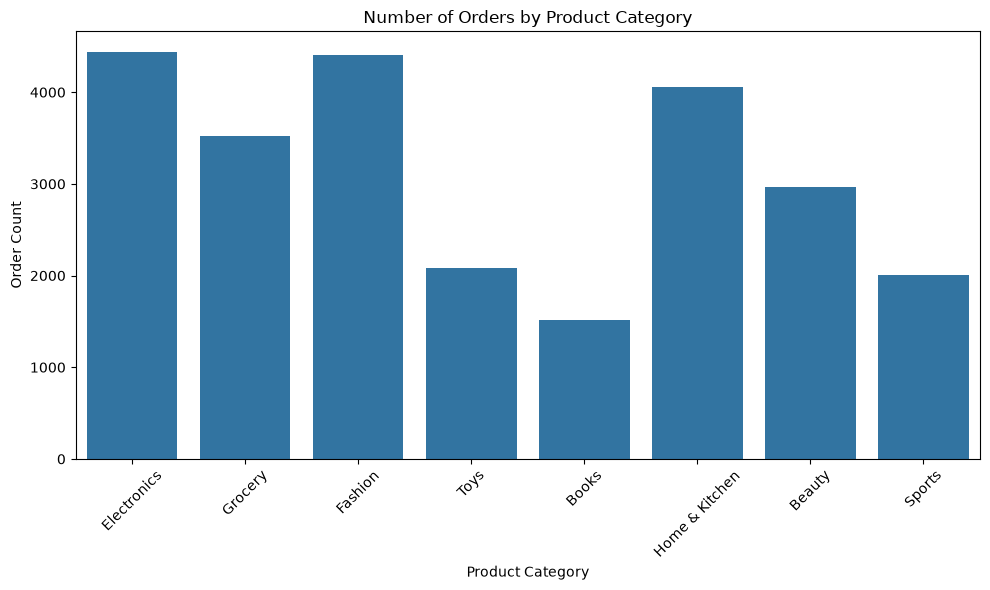

In [28]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=clean_df,
    x="Product_Category"
)

plt.title("Number of Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Order Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ANSWER : The chart compares the number of orders across different product categories. The category with the tallest bar has the highest number of orders.

## Q2. Which product category generates the highest revenue?

# Chart: Barplot

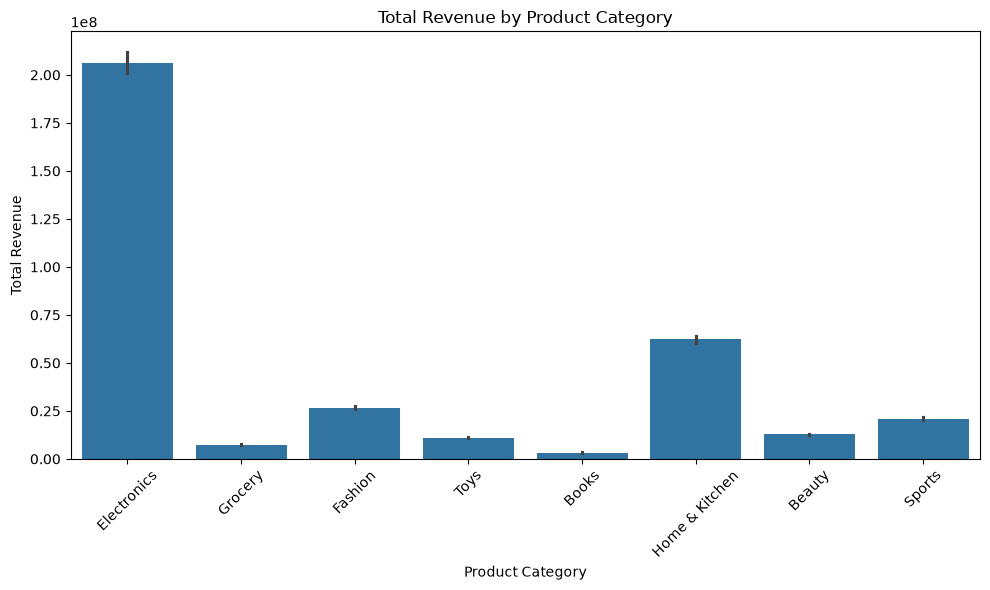

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=clean_df,
    x="Product_Category",
    y="Total_Amount",
    estimator="sum"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [30]:
# ANSWER

highest_revenue_category = (
    clean_df.groupby("Product_Category")["Total_Amount"]
    .sum()
    .idxmax()
)

highest_revenue = (
    clean_df.groupby("Product_Category")["Total_Amount"]
    .sum()
    .max()
)

print("Highest Revenue Category:", highest_revenue_category)
print("Revenue: ₹", round(highest_revenue, 2))

Highest Revenue Category: Electronics
Revenue: ₹ 206336009.1


# Q3. What is the distribution of order amounts?

# Chart: Histogram

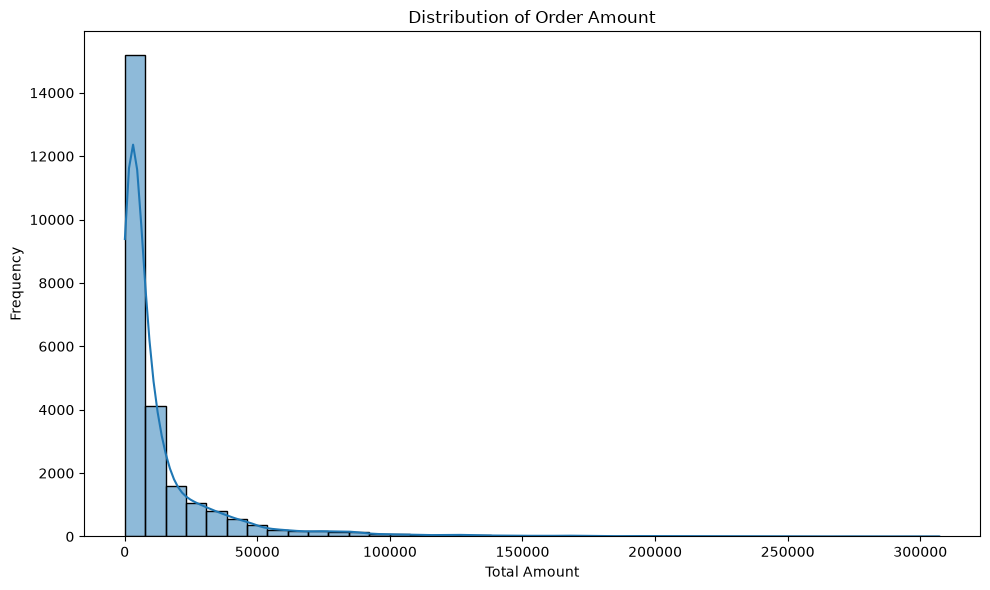

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=clean_df,
    x="Total_Amount",
    bins=40,
    kde=True
)

plt.title("Distribution of Order Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Answer:
# The histogram shows how frequently different order amounts occur. It helps identify the typical order-value range and whether the distribution is skewed.

## Q4. Which category has the highest variation in order value?

# Chart: Boxplot

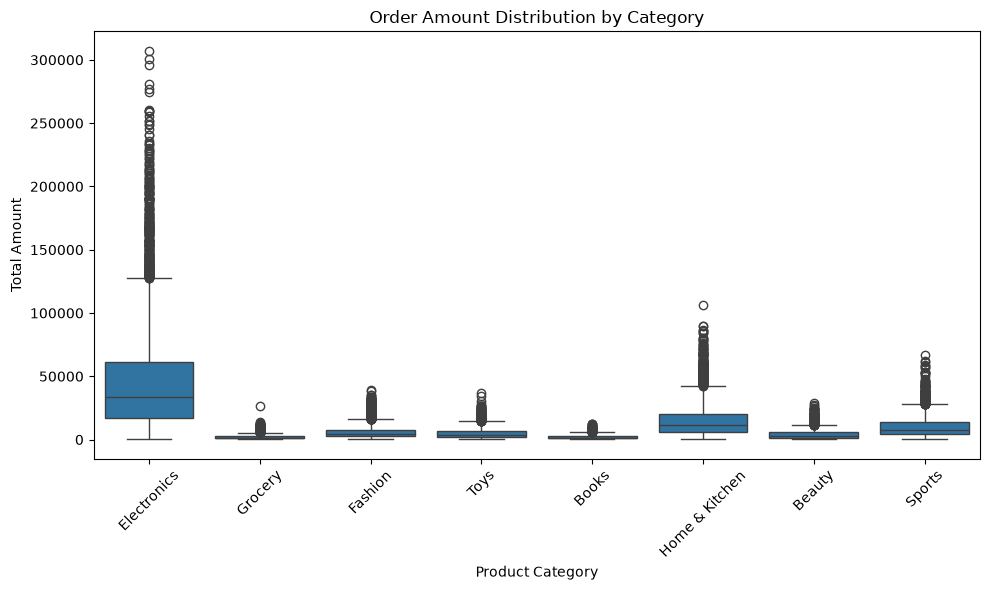

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="Product_Category",
    y="Total_Amount"
)

plt.title("Order Amount Distribution by Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Answer:

# The category with the largest box and/or longest whiskers has greater variation in order amounts. Points outside the whiskers indicate potential outliers.

## Q5. How are customer ratings distributed across categories?

# Chart: Violinplot

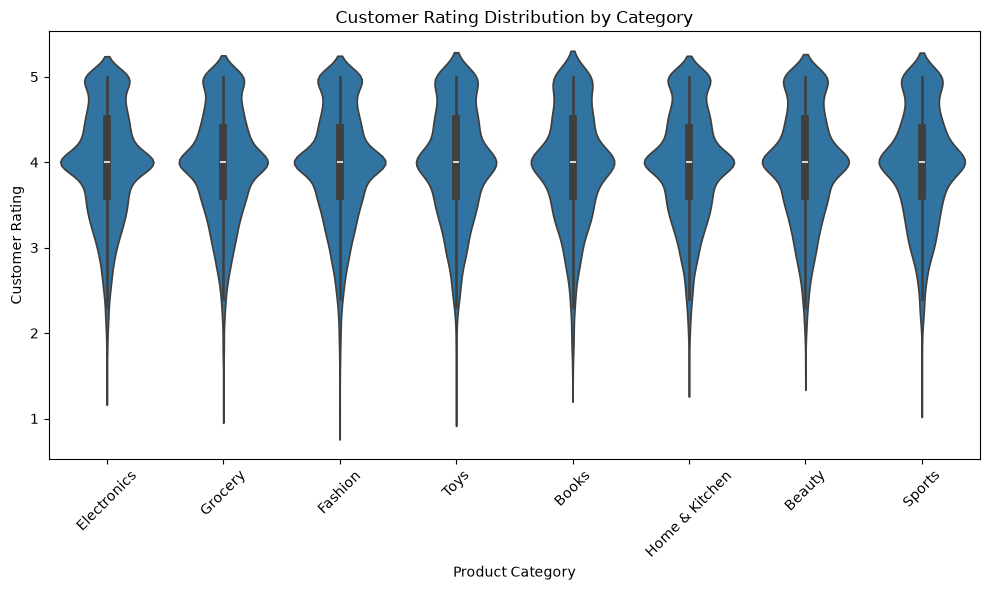

In [33]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=clean_df,
    x="Product_Category",
    y="Customer_Rating"
)

plt.title("Customer Rating Distribution by Category")
plt.xlabel("Product Category")
plt.ylabel("Customer Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Answer:

# The violin plot shows the distribution and concentration of ratings for each category. Wider sections indicate where more ratings are concentrated

## Q6. What is the average customer rating for each category?

# Chart: Pointplot

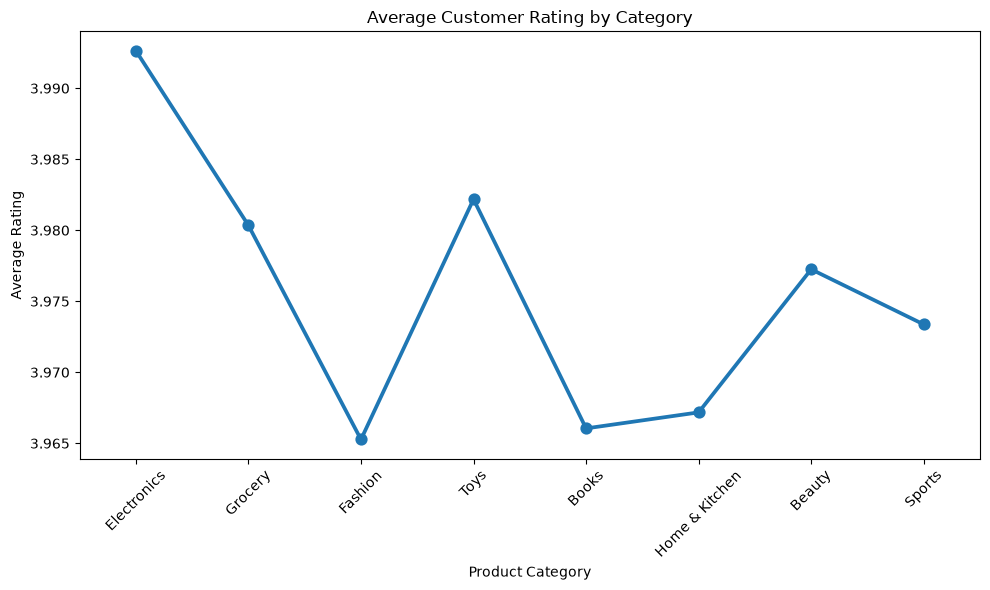

In [34]:
plt.figure(figsize=(10, 6))

sns.pointplot(
    data=clean_df,
    x="Product_Category",
    y="Customer_Rating",
    errorbar=None
)

plt.title("Average Customer Rating by Category")
plt.xlabel("Product Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ANSWER : The category at the top has the highest average customer rating


# Q7. Is there a relationship between discount and order amount?

# Chart: Scatterplot

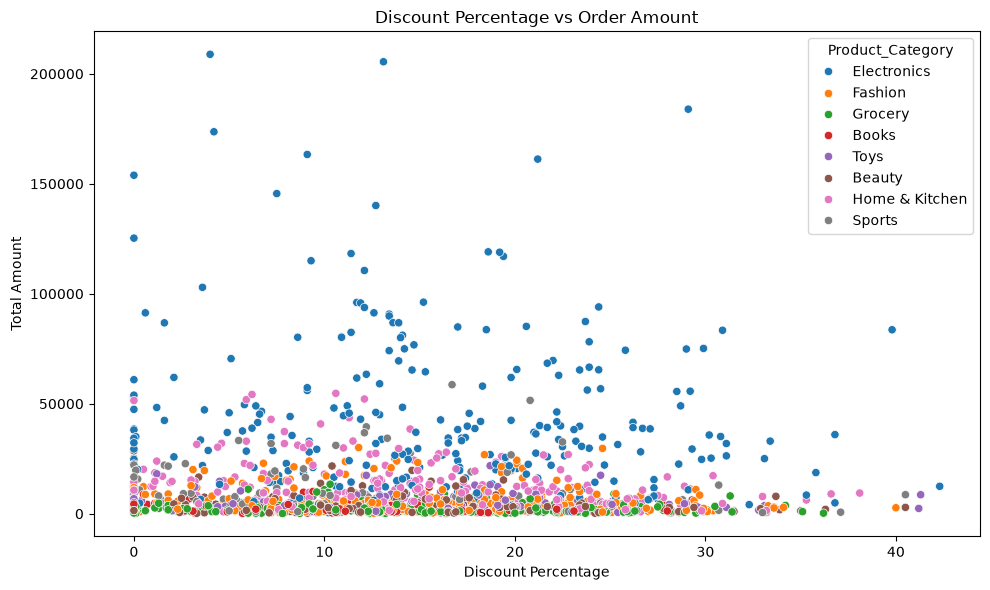

In [35]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df.sample(1500, random_state=42),
    x="Discount_Percentage",
    y="Total_Amount",
    hue="Product_Category"
)

plt.title("Discount Percentage vs Order Amount")
plt.xlabel("Discount Percentage")
plt.ylabel("Total Amount")

plt.tight_layout()
plt.show()

# Answer:

# The scatterplot helps determine whether higher discounts are associated with higher or lower order values. The different categories can also be compared using the hue parameter

# Q8. Does session duration have a relationship with order amount?


# Chart: Regression plot

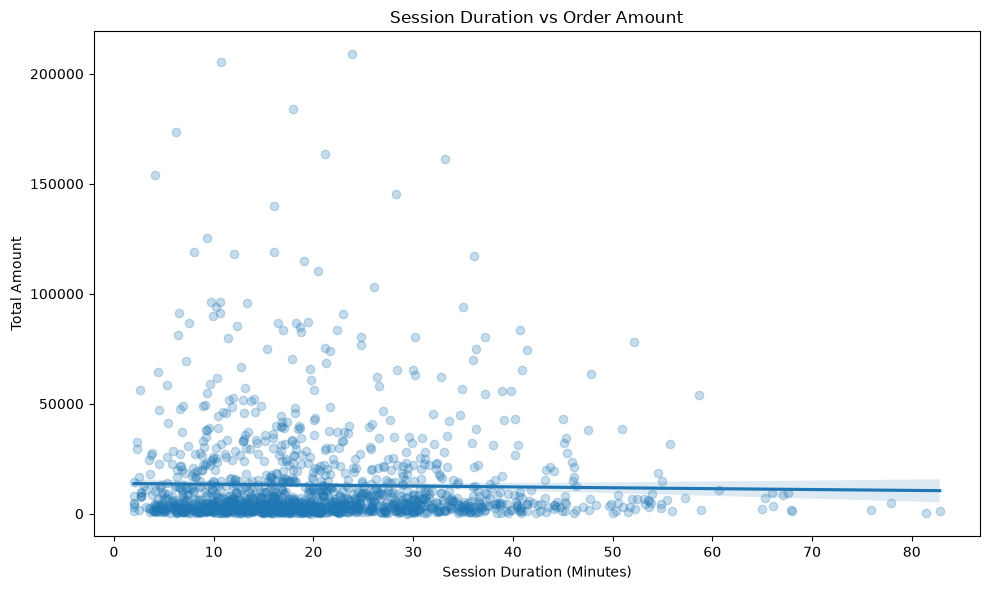

In [36]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=clean_df.sample(1500, random_state=42),
    x="Session_Duration_Min",
    y="Total_Amount",
    scatter_kws={"alpha": 0.25}
)

plt.title("Session Duration vs Order Amount")
plt.xlabel("Session Duration (Minutes)")
plt.ylabel("Total Amount")

plt.tight_layout()
plt.show()

# Answer:

# The regression line indicates the overall relationship between website session duration and order value

# Q9. Which payment method has the highest average order value?

# Chart: Barplot

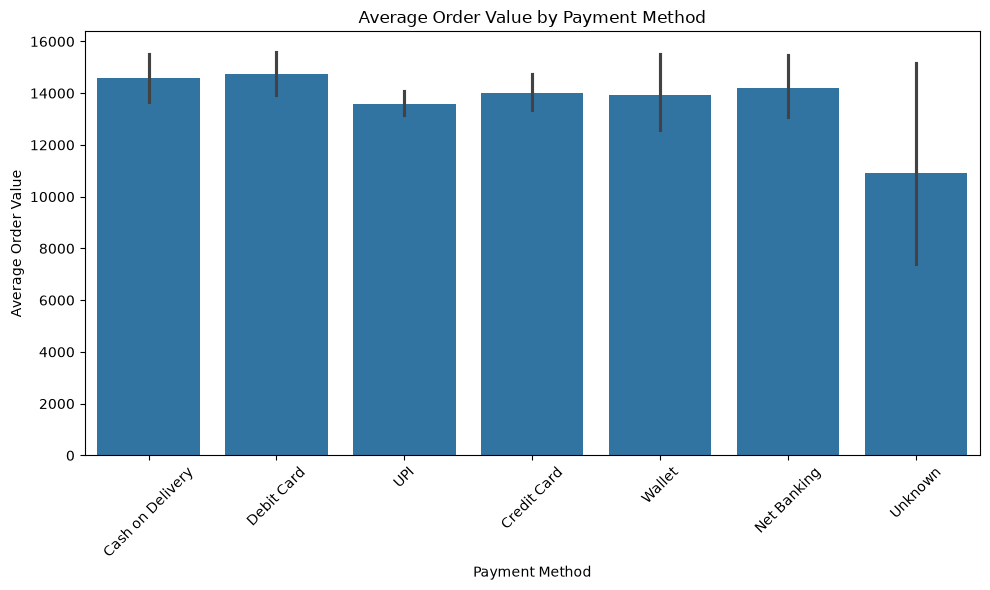

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=clean_df,
    x="Payment_Method",
    y="Total_Amount",
    estimator="mean"
)

plt.title("Average Order Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ANSWER

In [38]:
payment_aov = (
    clean_df.groupby("Payment_Method")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)

print(payment_aov)

print(
    "\nBest Payment Method:",
    payment_aov.idxmax()
)

Payment_Method
Debit Card          14736.686609
Cash on Delivery    14572.169800
Net Banking         14205.262424
Credit Card         14023.961907
Wallet              13949.365625
UPI                 13586.228470
Unknown             10915.084889
Name: Total_Amount, dtype: float64

Best Payment Method: Debit Card


# Q10. Which device type generates higher order values?

# Chart: Boxplot

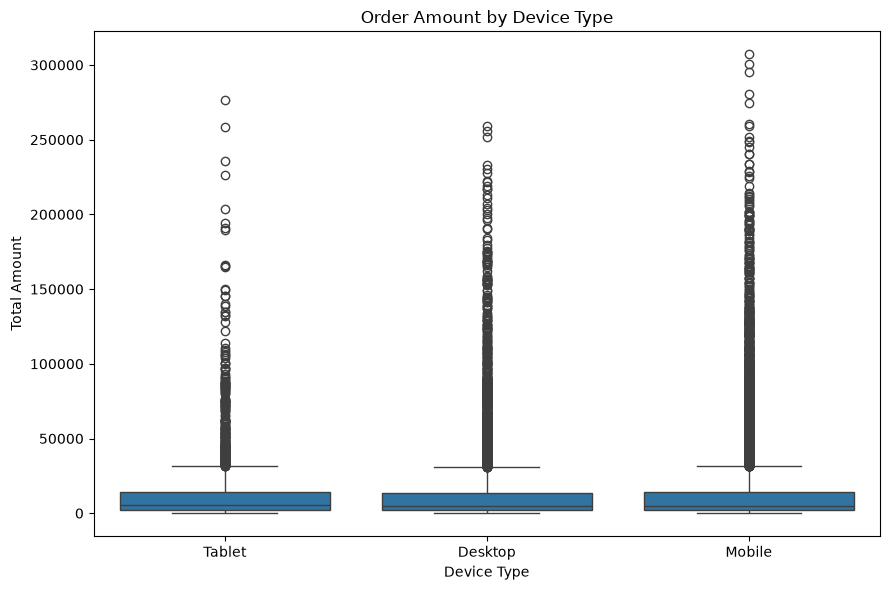

In [39]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_df,
    x="Device_Type",
    y="Total_Amount"
)

plt.title("Order Amount by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Total Amount")

plt.tight_layout()
plt.show()

# Answer:

# Compare the median order amount for Mobile, Desktop, and Tablet users. The device with the highest median represents the strongest typical order value.

# Q11. Which marketing channel generates the most revenue?

# Chart: Barplot

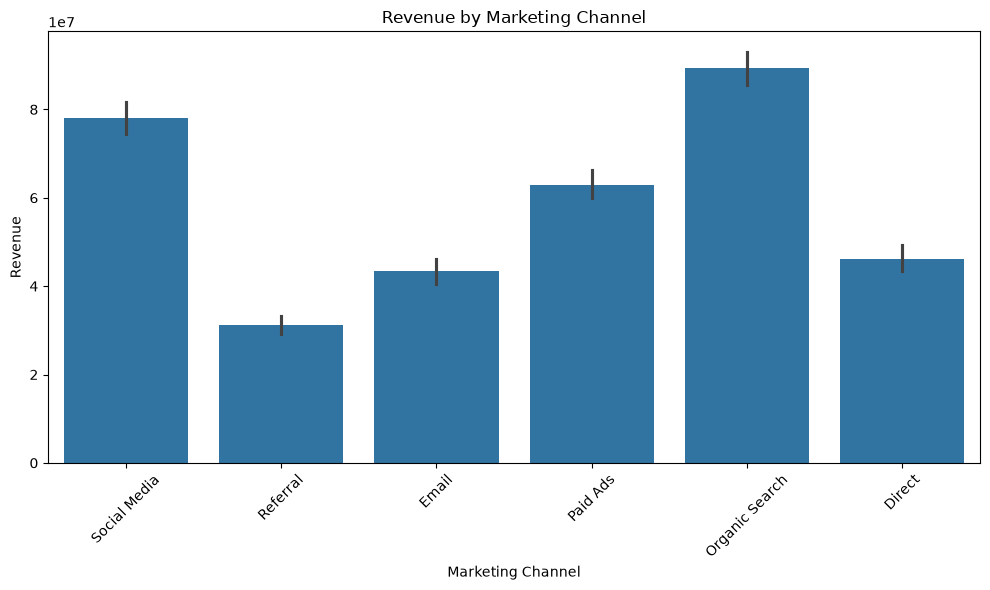

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=clean_df,
    x="Marketing_Channel",
    y="Total_Amount",
    estimator="sum"
)

plt.title("Revenue by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
# ANSWER

marketing_revenue = (
    clean_df.groupby("Marketing_Channel")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(marketing_revenue)

print(
    "\nBest Marketing Channel:",
    marketing_revenue.idxmax()
)

Marketing_Channel
Organic Search    89388994.94
Social Media      78015390.69
Paid Ads          62884288.72
Direct            46159179.77
Email             43325215.60
Referral          31168892.20
Name: Total_Amount, dtype: float64

Best Marketing Channel: Organic Search


# Q12. What is the relationship between unit price and total amount?

#  Chart: Jointplot

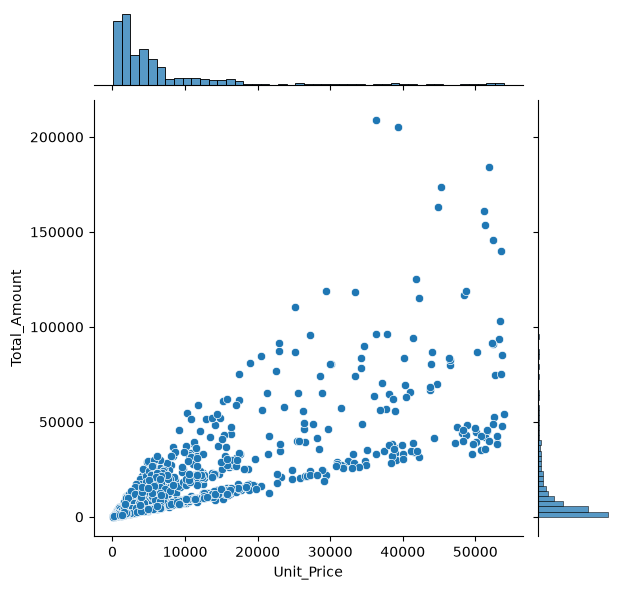

In [42]:
sns.jointplot(
    data=clean_df.sample(1500, random_state=42),
    x="Unit_Price",
    y="Total_Amount",
    kind="scatter"
)

plt.show()

# Answer:

# The jointplot shows the relationship between product price and total order amount along with their individual distributions.

# Q13. What is the correlation between numerical variables?

#  Chart: Heatmap

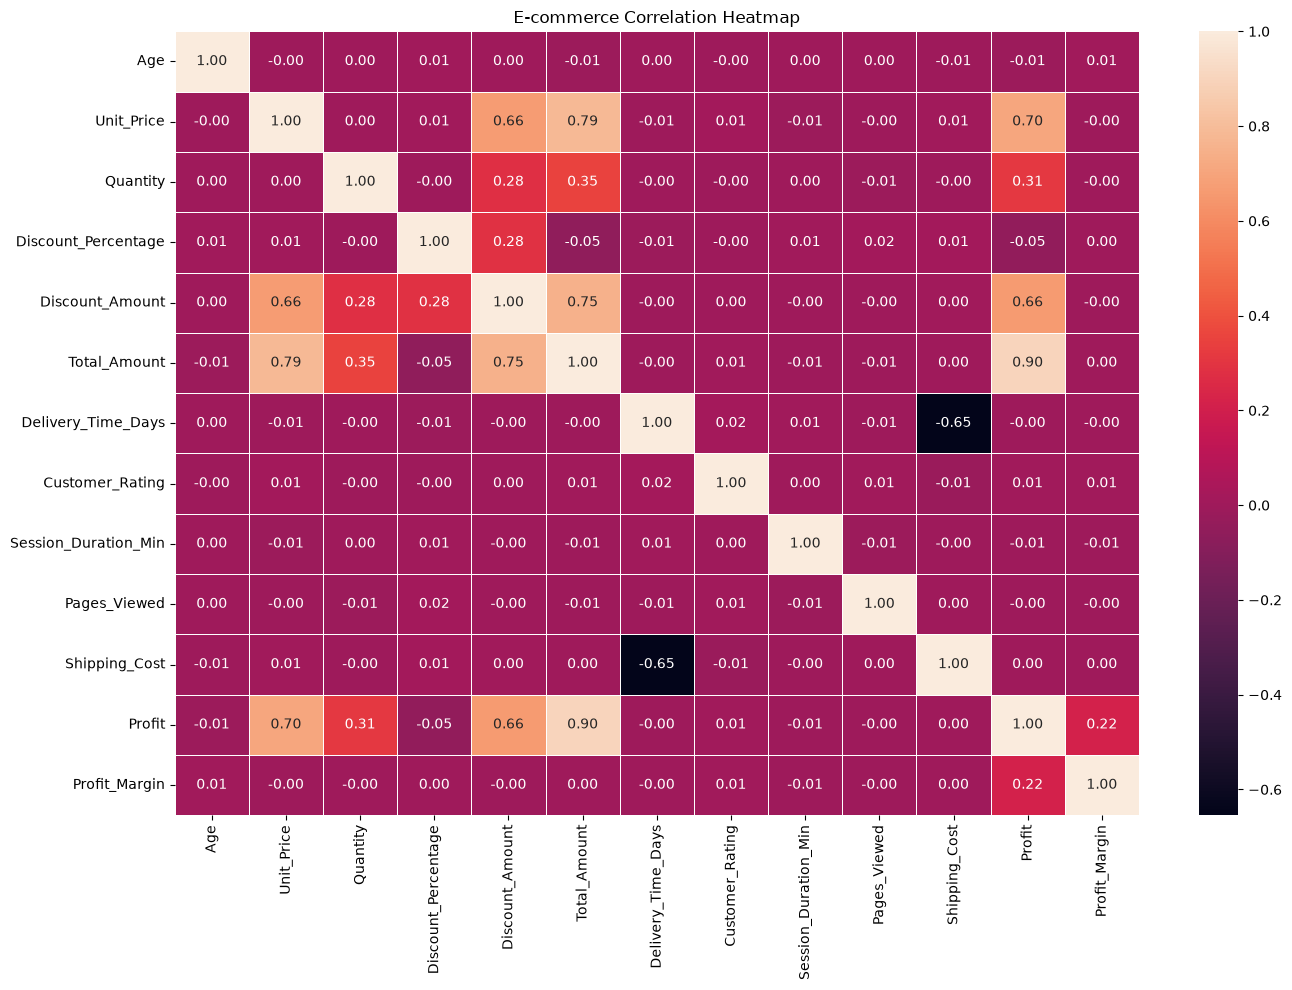

In [43]:
numeric_cols = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount_Percentage",
    "Discount_Amount",
    "Total_Amount",
    "Delivery_Time_Days",
    "Customer_Rating",
    "Session_Duration_Min",
    "Pages_Viewed",
    "Shipping_Cost",
    "Profit",
    "Profit_Margin"
]

corr = clean_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("E-commerce Correlation Heatmap")

plt.tight_layout()
plt.show()

<!-- Answer:
Values close to:

+1 → strong positive relationship
-1 → strong negative relationship
0 → weak/no linear relationship

For example, Unit_Price, Quantity, and Total_Amount can be examined to understand what contributes to revenue -->

# Q14. How are ratings distributed?

# Chart: KDE Plot

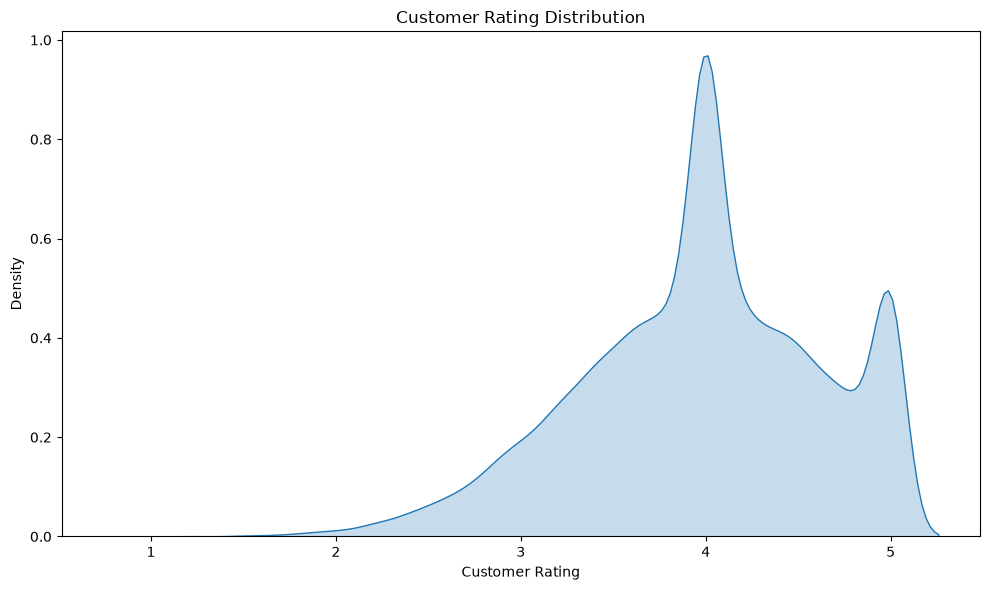

In [44]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=clean_df,
    x="Customer_Rating",
    fill=True
)

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

# Answer:

# The peak of the KDE curve represents the rating range where observations are most concentrated.

# Q15. Which categories have the highest and lowest customer ratings?

# Chart: Barplot

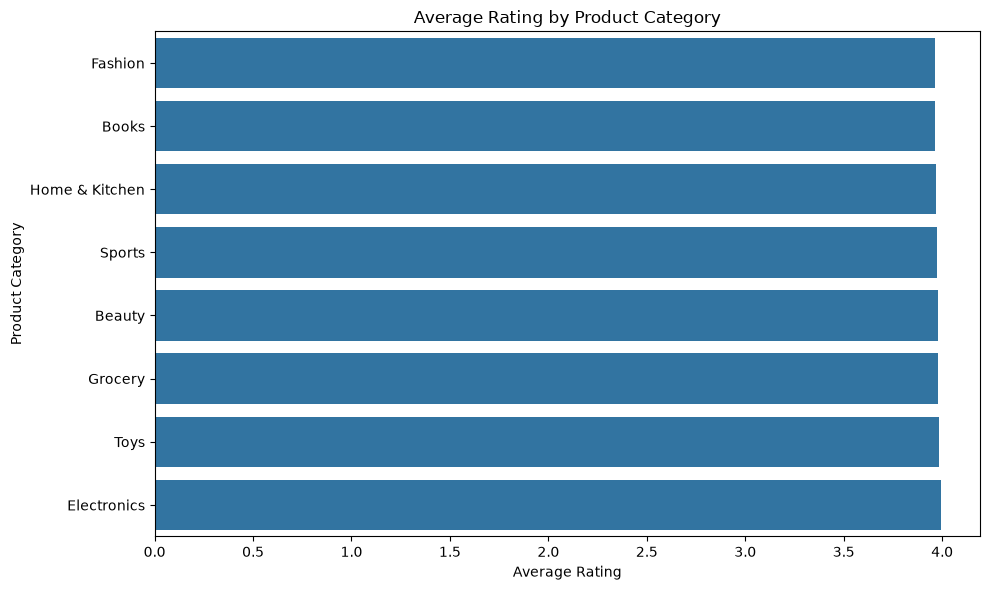

In [45]:
rating_category = (
    clean_df.groupby("Product_Category")["Customer_Rating"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=rating_category.values,
    y=rating_category.index
)

plt.title("Average Rating by Product Category")
plt.xlabel("Average Rating")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [46]:
# ANSWER

print("Lowest Rated Category:", rating_category.idxmin())
print("Highest Rated Category:", rating_category.idxmax())

Lowest Rated Category: Fashion
Highest Rated Category: Electronics


# 16. Order Status by Customer Segment

# Chart: Countplot with hue

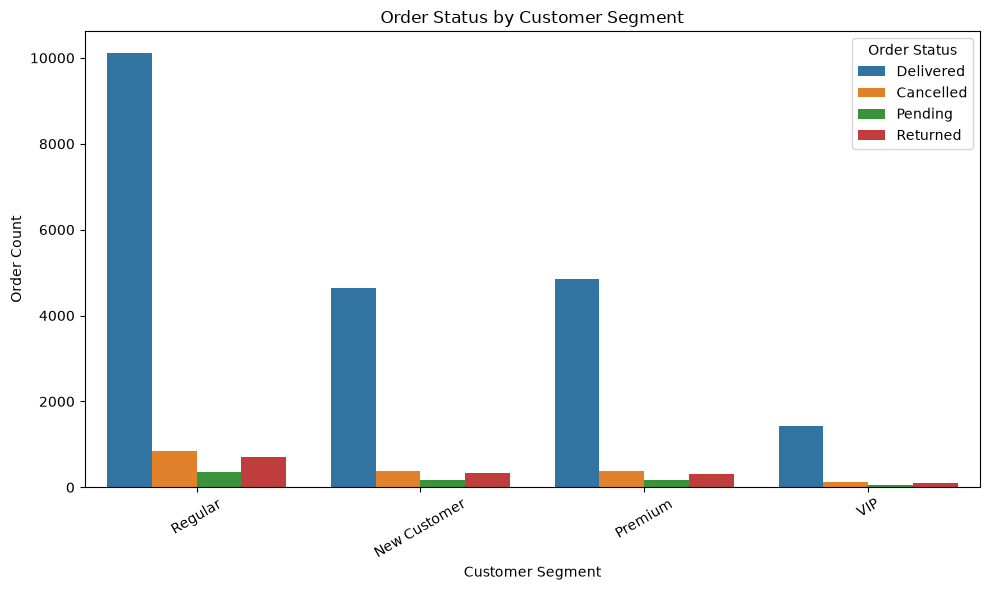

In [47]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=clean_df,
    x="Customer_Segment",
    hue="Order_Status"
)

plt.title("Order Status by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Order Count")
plt.xticks(rotation=30)

plt.legend(title="Order Status")
plt.tight_layout()
plt.show()

# ANSWER :

# This chart compares delivered, cancelled, returned, and pending orders across customer segments.

# 17. Top 10 Cities by Revenue

# Chart: Barplot

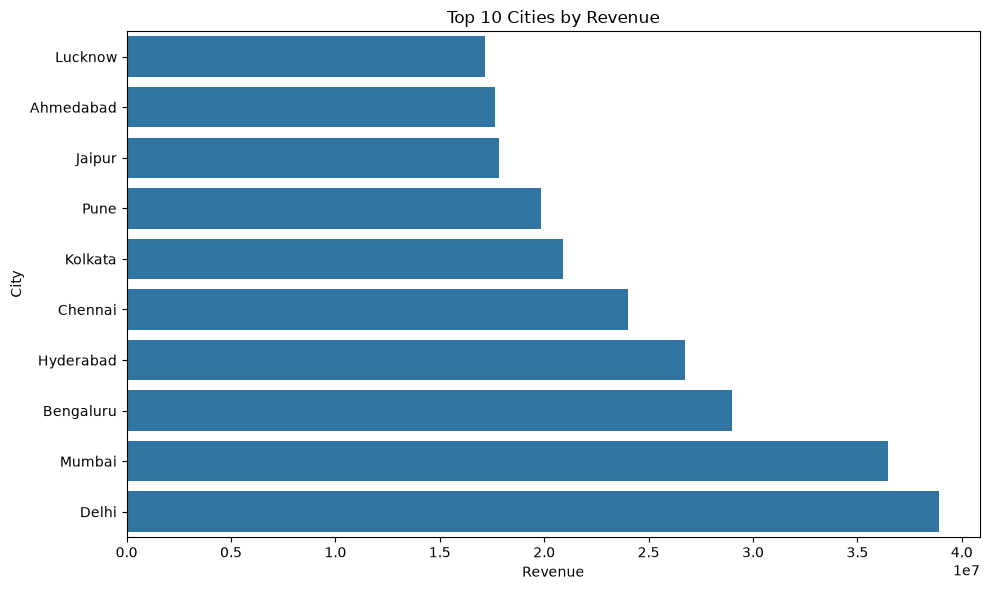

In [48]:
top_cities = (
    clean_df.groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [49]:
# Answer:

print(top_cities.sort_values(ascending=False))

# The first city has the highest revenue among the top 10 cities

City
Delhi        38926146.30
Mumbai       36476028.75
Bengaluru    28991935.26
Hyderabad    26739696.45
Chennai      24006554.30
Kolkata      20895859.09
Pune         19840618.30
Jaipur       17827289.95
Ahmedabad    17660198.09
Lucknow      17165156.28
Name: Total_Amount, dtype: float64


# Q 18.  Which are the top 10 cities by revenue?

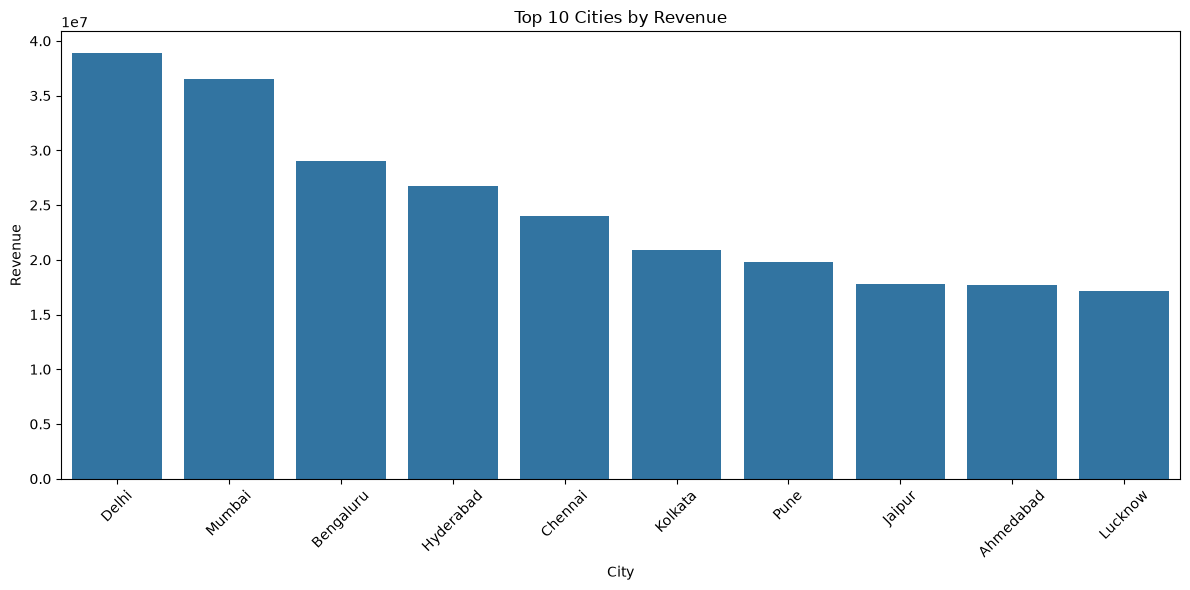

        City  Total_Amount
0      Delhi   38926146.30
1     Mumbai   36476028.75
2  Bengaluru   28991935.26
3  Hyderabad   26739696.45
4    Chennai   24006554.30
5    Kolkata   20895859.09
6       Pune   19840618.30
7     Jaipur   17827289.95
8  Ahmedabad   17660198.09
9    Lucknow   17165156.28


In [51]:
city_revenue = (
    clean_df.groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=city_revenue,
    x="City",
    y="Total_Amount"
)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(city_revenue)



# Q 19.  Which product category is best overall?

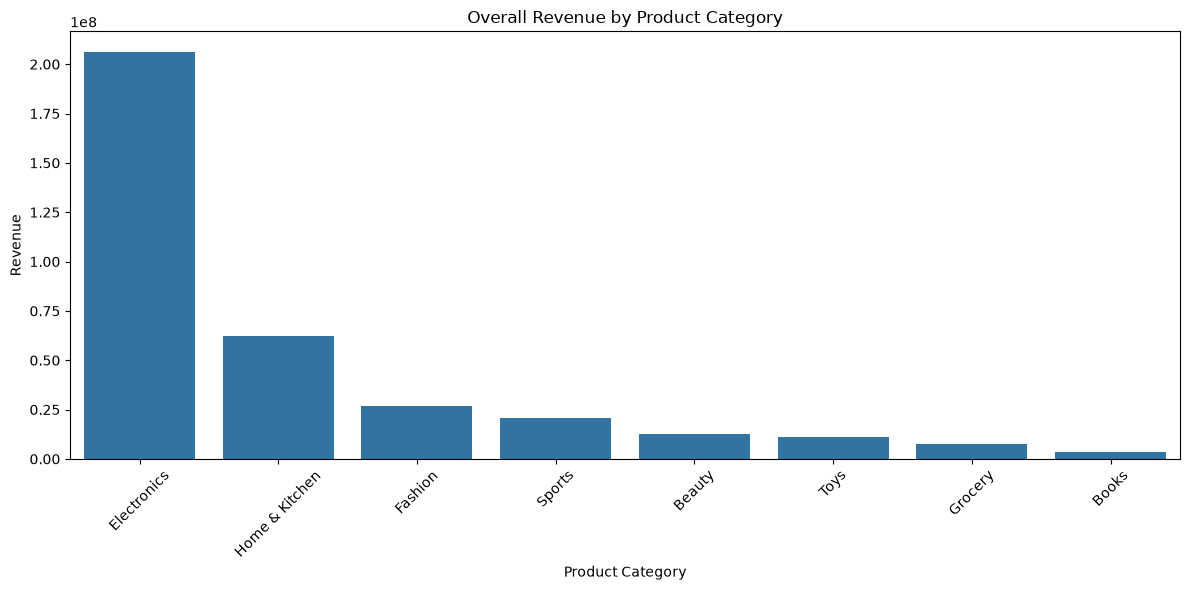

                  Orders       Revenue       Profit  Avg_Rating  \
Product_Category                                                  
Electronics         4442  2.063360e+08  37275255.47    3.992638   
Home & Kitchen      4058  6.226249e+07  11285870.66    3.967176   
Fashion             4405  2.678321e+07   4827416.87    3.965267   
Sports              2009  2.097905e+07   3690135.24    3.973370   
Beauty              2967  1.278046e+07   2327031.16    3.977250   
Toys                2088  1.106514e+07   1994377.09    3.982184   
Grocery             3520  7.392816e+06   1352273.21    3.980341   
Books               1511  3.342785e+06    598947.36    3.966049   

                  Avg_Order_Value  
Product_Category                   
Electronics          46451.150180  
Home & Kitchen       15343.146272  
Fashion               6080.184052  
Sports               10442.534903  
Beauty                4307.537027  
Toys                  5299.396025  
Grocery               2100.231750  
Books

In [52]:
category_analysis = (
    clean_df.groupby("Product_Category")
    .agg(
        Orders=("Order_ID", "count"),
        Revenue=("Total_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Rating=("Customer_Rating", "mean"),
        Avg_Order_Value=("Total_Amount", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_analysis.reset_index(),
    x="Product_Category",
    y="Revenue"
)

plt.title("Overall Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print(category_analysis)



# 20. Complete Business Insight

In [50]:
highest_category = (
    clean_df.groupby("Product_Category")["Total_Amount"]
    .sum()
    .idxmax()
)

highest_city = (
    clean_df.groupby("City")["Total_Amount"]
    .sum()
    .idxmax()
)

highest_product = (
    clean_df.groupby("Product_Name")["Total_Amount"]
    .sum()
    .idxmax()
)

best_payment = (
    clean_df.groupby("Payment_Method")["Total_Amount"]
    .mean()
    .idxmax()
)

best_segment = (
    clean_df.groupby("Customer_Segment")["Total_Amount"]
    .sum()
    .idxmax()
)

print("===== BUSINESS INSIGHTS =====")
print("Highest Revenue Category:", highest_category)
print("Highest Revenue City:", highest_city)
print("Top Product:", highest_product)
print("Best Payment Method by AOV:", best_payment)
print("Top Customer Segment:", best_segment)

===== BUSINESS INSIGHTS =====
Highest Revenue Category: Electronics
Highest Revenue City: Delhi
Top Product: Smartphone
Best Payment Method by AOV: Debit Card
Top Customer Segment: Regular


# FINAL CONCLUSION ....


<!-- The correlation and relationship analysis also helped understand how variables such as unit price, quantity, discount, session duration, pages viewed, total amount, and profit are related.

💡 Key Business Takeaways
Identify and focus on high-revenue and high-profit product categories.
Target high-value customer segments with personalized offers.
Invest more in high-performing marketing channels.
Optimize discounts to increase sales without significantly reducing profit.
Improve delivery performance to maintain better customer ratings.
Analyze payment and device preferences to improve the customer shopping experience.
Monitor cart abandonment, cancellations, and returns to reduce lost revenue.
Use customer and sales data for targeted marketing and retention strategies.
🎯 Final Statement

Overall, this E-commerce EDA demonstrates how Python, Pandas, Matplotlib, and Seaborn can transform raw e-commerce data into meaningful business insights. The analysis can help businesses improve sales, profitability, customer satisfaction, marketing performance, and decision-making -->

<!-- The analysis showed that sales and profit are influenced by multiple factors, including product category, quantity purchased, discounts, customer segment, payment method, device type, and marketing channel. Seaborn visualizations helped identify differences in order values, customer ratings, delivery times, and purchasing behavior across different groups.

The correlation and relationship analysis also helped understand how variables such as unit price, quantity, discount, session duration, pages viewed, total amount, and profit are related.

💡 Key Business Takeaways
Identify and focus on high-revenue and high-profit product categories.
Target high-value customer segments with personalized offers.
Invest more in high-performing marketing channels.
Optimize discounts to increase sales without significantly reducing profit.
Improve delivery performance to maintain better customer ratings.
Analyze payment and device preferences to improve the customer shopping experience.
Monitor cart abandonment, cancellations, and returns to reduce lost revenue.
Use customer and sales data for targeted marketing and retention strategies. -->